In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# Load all outputs
X_scaled  = pd.read_csv('X_scaled.csv')
labels_df = pd.read_csv('phase3_labels.csv')
scaler    = joblib.load('scaler.pkl')
X_pca     = np.load('X_pca.npy')

# Attach K-Means labels (best model) to original scaled data
X_scaled['cluster'] = labels_df['kmeans']

# Recover original-scale values for interpretable profiling
X_original = pd.DataFrame(
    scaler.inverse_transform(X_scaled.drop('cluster', axis=1)),
    columns=X_scaled.drop('cluster', axis=1).columns
)
X_original['cluster'] = labels_df['kmeans']

print(f'Loaded: {X_scaled.shape[0]} customers, {X_scaled.shape[1]-1} features, 4 clusters')
print('\nCluster sizes:')
print(X_original['cluster'].value_counts().sort_index())

Loaded: 8950 customers, 17 features, 4 clusters

Cluster sizes:
cluster
0    2141
1    2718
2    2435
3    1656
Name: count, dtype: int64


Cluster summary statistics

In [2]:
# Mean of every feature per cluster — this is your profiling table
profile = X_original.groupby('cluster').mean().round(2)

print('Cluster profiles (original scale means):')
print(profile.T.to_string())  # .T = features as rows, clusters as columns

profile.T.to_csv('cluster_profiles.csv')
print('\nSaved: cluster_profiles.csv')

Cluster profiles (original scale means):
cluster                                0        1        2       3
BALANCE                             4.97     7.39     7.16    4.21
BALANCE_FREQUENCY                   0.90     0.94     0.98    0.60
PURCHASES                           6.16     1.57     7.45    4.97
ONEOFF_PURCHASES                    1.30     1.22     6.64    3.83
INSTALLMENTS_PURCHASES              6.04     0.48     5.31    1.68
CASH_ADVANCE                        0.72     6.99     3.10    0.96
PURCHASES_FREQUENCY                 0.82     0.07     0.85    0.23
ONEOFF_PURCHASES_FREQUENCY          0.05     0.04     0.56    0.14
PURCHASES_INSTALLMENTS_FREQUENCY    0.77     0.03     0.58    0.08
CASH_ADVANCE_FREQUENCY              0.02     0.30     0.12    0.02
CASH_ADVANCE_TRX                    0.14     1.78     0.77    0.16
PURCHASES_TRX                       2.60     0.42     3.31    1.31
CREDIT_LIMIT                        7.73     8.09     8.56    7.90
PAYMENTS             

The four segments:
C0 — Installment buyers (2,141 customers, 23.9%)
High purchases via installments (6.04), high purchase frequency (0.82), low cash advance (0.72), highest full payment rate (0.29). These customers buy regularly and prefer structured payments. Lowest risk profile.
C1 — Cash-dependent users (2,718 customers, 30.4%)
Extremely high cash advance (6.99) and cash advance frequency (0.30), near-zero purchases (1.57) and purchase frequency (0.07), lowest full payment rate (0.03). These customers use their card primarily as a cash source — highest financial stress signal.
C2 — High-value transactors (2,435 customers, 27.2%)
Highest purchases overall (7.45), highest one-off purchases (6.64), highest credit limit (8.56), highest payments (2,895). These are your premium active spenders — high value to the bank.
C3 — Low-engagement users (1,656 customers, 18.5%)
Below-average on everything — moderate purchases (4.97), low frequency (0.23), low cash advance (0.96), lowest balance frequency (0.60). These customers use their card occasionally but aren't deeply engaged with any particular behavior.

 Name your clusters

In [8]:
# Fill these in after reading Block 2 output
CLUSTER_NAMES = {
    0: 'Installment buyers',
    1: 'Cash-dependent users',
    2: 'High-value transactors',
    3: 'Low-engagement users'
}

X_original['cluster_name'] = X_original['cluster'].map(CLUSTER_NAMES)
X_scaled['cluster_name']   = X_scaled['cluster'].map(CLUSTER_NAMES)

print('Cluster name mapping:')
for k, v in CLUSTER_NAMES.items():
    n = (X_original['cluster'] == k).sum()
    print(f'  C{k} ({n} customers, {n/len(X_original)*100:.1f}%): {v}')
    

Cluster name mapping:
  C0 (2141 customers, 23.9%): Installment buyers
  C1 (2718 customers, 30.4%): Cash-dependent users
  C2 (2435 customers, 27.2%): High-value transactors
  C3 (1656 customers, 18.5%): Low-engagement users


Centroid heatmap 

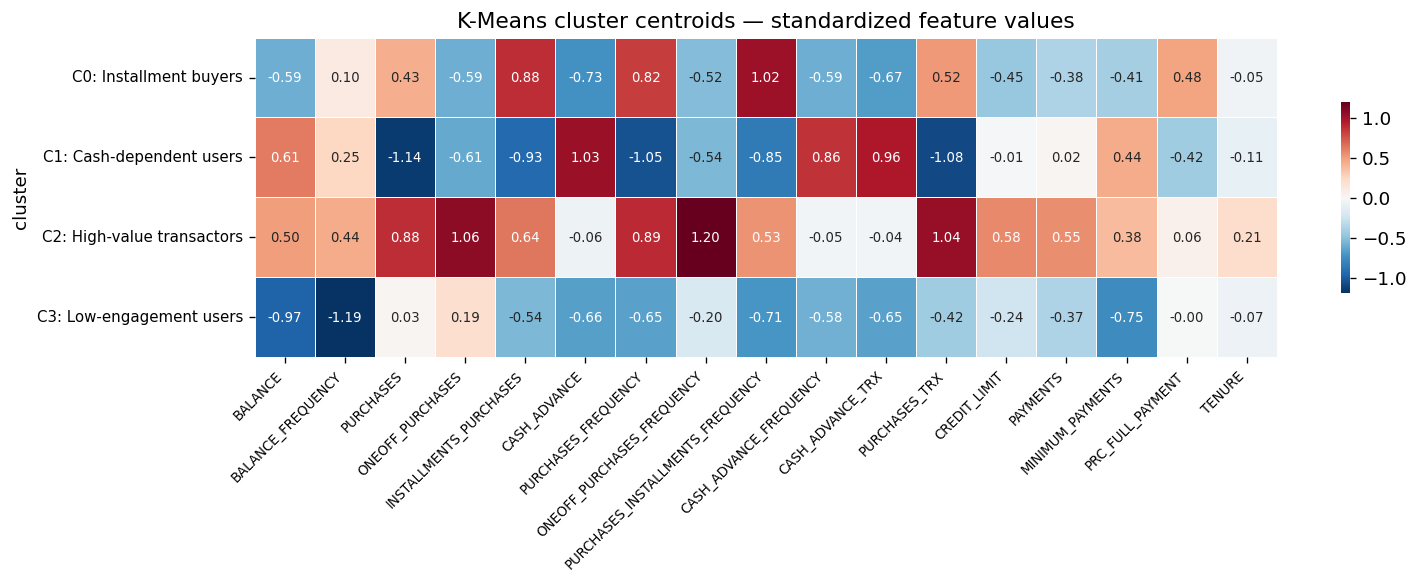

In [9]:
features = X_scaled.drop(['cluster', 'cluster_name'], axis=1).columns
centroids_scaled = X_scaled.groupby('cluster')[features].mean()

plt.figure(figsize=(13, 5))
sns.heatmap(
    centroids_scaled,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    annot_kws={'size': 8},
    yticklabels=[f'C{i}: {CLUSTER_NAMES[i]}' for i in centroids_scaled.index],
    cbar_kws={'shrink': 0.6}
)
plt.title('K-Means cluster centroids — standardized feature values', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('fig_centroid_heatmap.png', bbox_inches='tight')
plt.show()

Block 5 — Radar chart (most visually impressive paper figure)

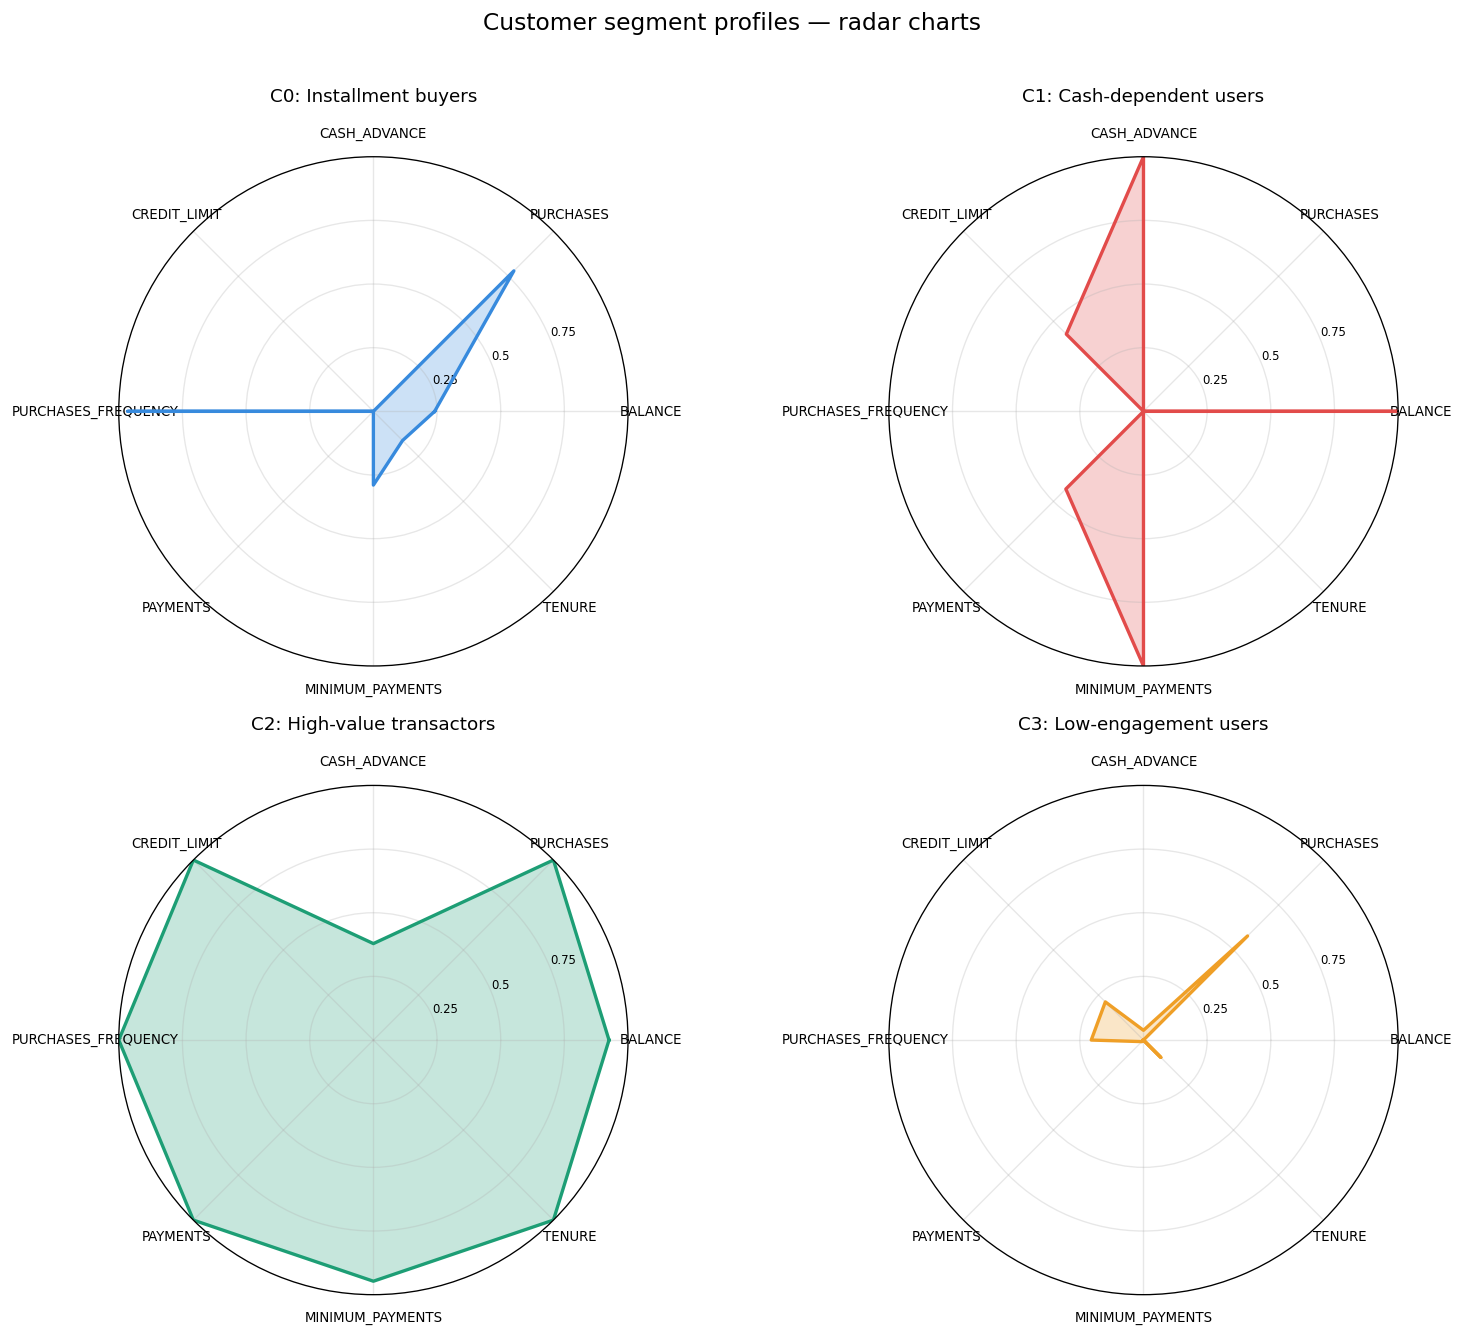

Saved: fig_radar_charts.png


In [10]:
from matplotlib.patches import FancyArrowPatch

# Select 8 most discriminating features for readability
RADAR_FEATURES = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
    'PURCHASES_FREQUENCY', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'TENURE'
]

# Normalize centroids to 0-1 for radar
radar_data = centroids_scaled[RADAR_FEATURES].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(RADAR_FEATURES), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

colors = ['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27']
fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (cluster_id, ax) in enumerate(zip(radar_norm.index, axes)):
    values = radar_norm.loc[cluster_id].tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_FEATURES, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.5', '0.75'], size=7)
    ax.set_title(f'C{cluster_id}: {CLUSTER_NAMES[cluster_id]}',
                 size=11, fontweight='normal', pad=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('Customer segment profiles — radar charts', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_radar_charts.png', bbox_inches='tight')
plt.show()
print('Saved: fig_radar_charts.png')

Parallel coordinates plot

C:\Users\omtil\AppData\Local\Temp\ipykernel_37340\1509025099.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = plot_data.groupby('cluster_name').apply(


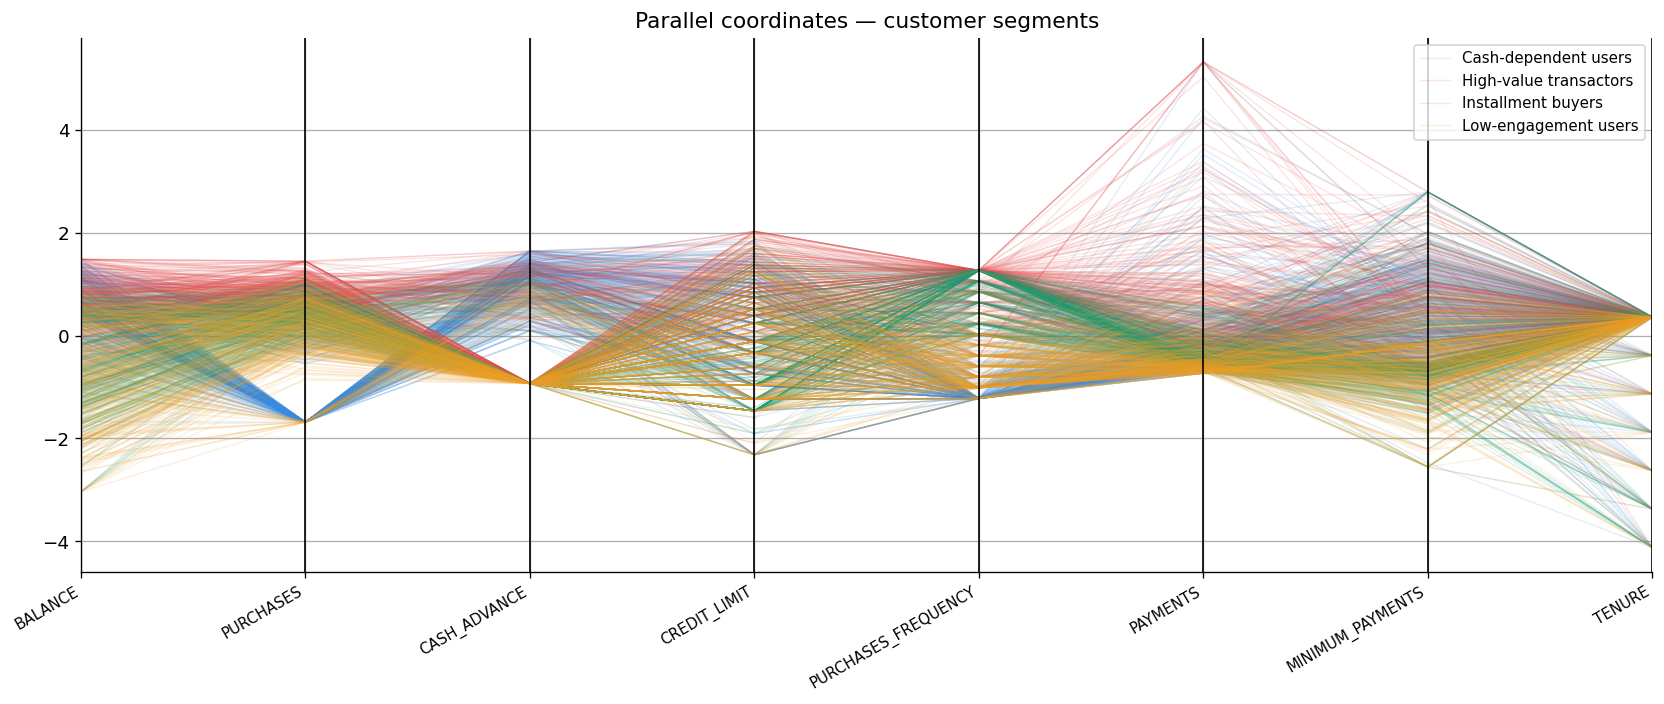

Saved: fig_parallel_coordinates.png


In [11]:
from pandas.plotting import parallel_coordinates

plot_data = X_scaled[RADAR_FEATURES + ['cluster_name']].copy()

# Sample for readability (full 8950 is too dense)
sample = plot_data.groupby('cluster_name').apply(
    lambda x: x.sample(min(300, len(x)), random_state=42)
).reset_index(drop=True)

plt.figure(figsize=(14, 6))
parallel_coordinates(
    sample, 'cluster_name',
    color=['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27'],
    alpha=0.15, linewidth=0.8
)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.title('Parallel coordinates — customer segments', fontsize=13)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_parallel_coordinates.png', bbox_inches='tight')
plt.show()
print('Saved: fig_parallel_coordinates.png')

 Cluster size bar chart

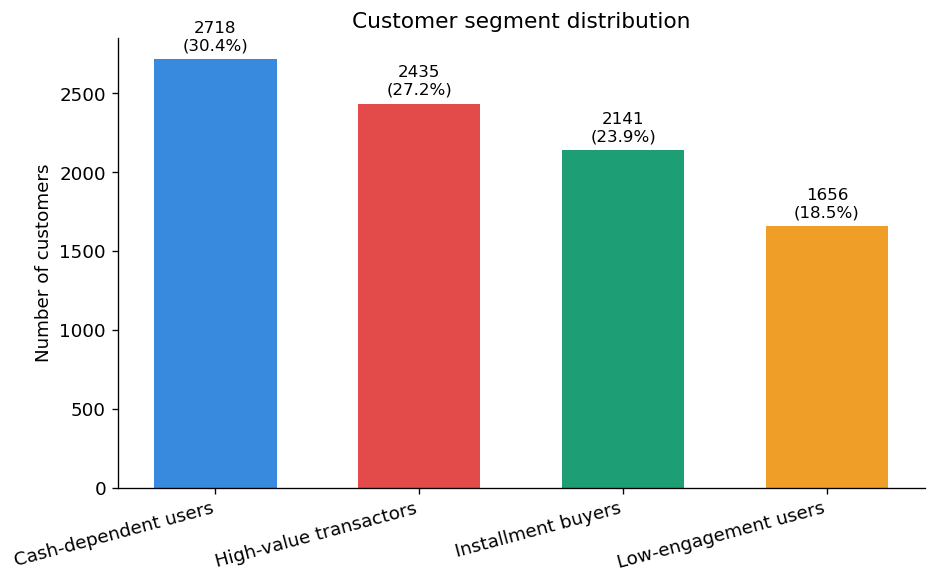

In [12]:
sizes = X_original['cluster_name'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(sizes.index, sizes.values,
               color=['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27'],
               edgecolor='none', width=0.6)

for bar, val in zip(bars, sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 40,
             f'{val}\n({val/len(X_original)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.ylabel('Number of customers')
plt.title('Customer segment distribution', fontsize=13)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig_cluster_sizes.png', bbox_inches='tight')
plt.show()